# Exploration: retail and office electricity (BDG2, real data)

A short look at the cleaned data, top to bottom. **Data:** Building Data Genome Project 2, a public dataset of real hourly meter readings; electricity only; the year chosen by the pipeline. Every number below is computed in the cell that prints it.

Run the pipeline first (`make all`); this notebook only reads its outputs in `data/processed/`.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))
import plotstyle as ps
ps.apply()
%matplotlib inline

P = ROOT / 'data' / 'processed'
dim_b = pd.read_csv(P / 'dim_building.csv')
daily = pd.read_csv(P / 'fact_daily_energy.csv', parse_dates=['date'])
hourly = pd.read_csv(P / 'fact_hourly_energy.csv', parse_dates=['timestamp'])
annual = pd.read_csv(P / 'fact_annual_kpi.csv')
dq = pd.read_csv(P / 'data_quality_report.csv')
anom = pd.read_csv(P / 'fact_anomalies.csv')
YEAR = int(dim_b['year'].iloc[0])
print(f'{len(dim_b)} buildings, year {YEAR}; {len(hourly):,} hourly rows, {len(daily):,} daily rows')

25 buildings, year 2017; 219,000 hourly rows, 9,125 daily rows


## 1. Which buildings?

Retail buildings in BDG2 are few, so offices from the same sites were added. Floor area matters because EUI divides by it.

In [2]:
dim_b.groupby(['type', 'site', 'country']).agg(buildings=('building_id', 'size'),
    median_floor_area_m2=('floor_area_m2', 'median')).round(0)

buildings  median_floor_area_m2
type   site    country                                 
Office Fox     USA              4                2653.0
       Panther USA              4                2802.0
       Rat     USA              4                3248.0
       Wolf    Ireland          4                4076.0
Retail Fox     USA              1                4201.0
       Panther USA              4                4215.0
       Rat     USA              1                1533.0
       Wolf    Ireland          3                4108.0

## 2. Data quality at a glance

All candidate buildings were checked; only those that passed were kept.

In [3]:
print(dq.groupby(['building_type', 'quality_flag']).size().to_string())
cols = ['missing_values', 'zero_readings', 'flatline_hours', 'spike_readings', 'filled_hours', 'excluded_hours']
dq.loc[dq['selected'], cols].sum().rename('hours (selected buildings)').to_frame()

building_type  quality_flag   
Office         fail                8
               pass_with_fixes    73
Retail         fail                2
               pass_with_fixes     9


,hours (selected buildings)
missing_values,491
zero_readings,267
flatline_hours,78
spike_readings,0
filled_hours,112
excluded_hours,724


## 3. What does a typical day look like?

Average load by hour of day, weekdays vs weekends, scaled by floor area so big and small buildings can share one chart. This is where opening hours, baseload and after-hours use become visible.

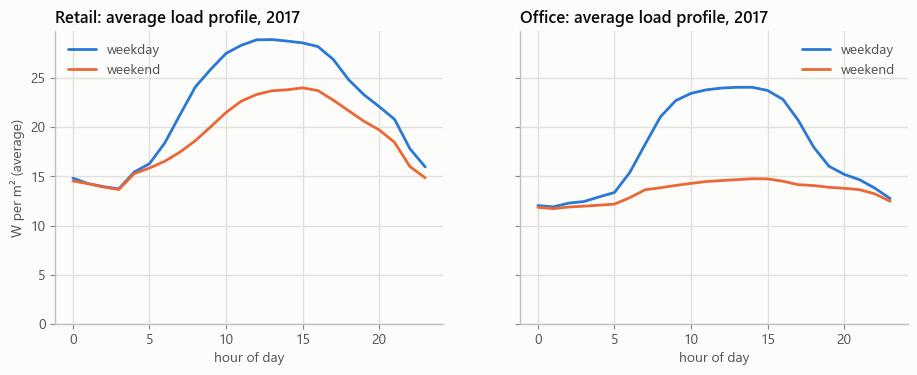

night (01-04h) load as share of peak:
type    day    
Office  weekday    0.51
        weekend    0.81
Retail  weekday    0.50
        weekend    0.59


In [4]:
h = hourly.merge(dim_b[['building_id', 'type', 'floor_area_m2']], on='building_id')
h['w_per_m2'] = h['kwh'] * 1000 / h['floor_area_m2']   # kWh in one hour = average kW
h['day'] = h['timestamp'].dt.dayofweek.map(lambda d: 'weekend' if d >= 5 else 'weekday')
prof = h.groupby(['type', 'day', 'hour'])['w_per_m2'].mean().unstack(['type', 'day'])
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, t in zip(axes, ['Retail', 'Office']):
    ax.plot(prof.index, prof[(t, 'weekday')], color=ps.SERIES[0], label='weekday')
    ax.plot(prof.index, prof[(t, 'weekend')], color=ps.SERIES[1], label='weekend')
    ax.set_title(f'{t}: average load profile, {YEAR}'); ax.set_xlabel('hour of day'); ax.legend()
axes[0].set_ylabel('W per m² (average)'); axes[0].set_ylim(bottom=0)
plt.show()
night = prof.loc[[1, 2, 3, 4]].mean(); peak = prof.max()
print('night (01-04h) load as share of peak:'); print((night / peak).round(2).to_string())

**Reading it:** the night-time level is the baseload, the always-on part (servers, refrigeration, ventilation, security lighting). A night level that is a large share of the peak means a lot of energy is used when nobody is in the building.

## 4. Does temperature drive consumption?

Daily kWh against daily mean outdoor temperature for the largest building of each type.

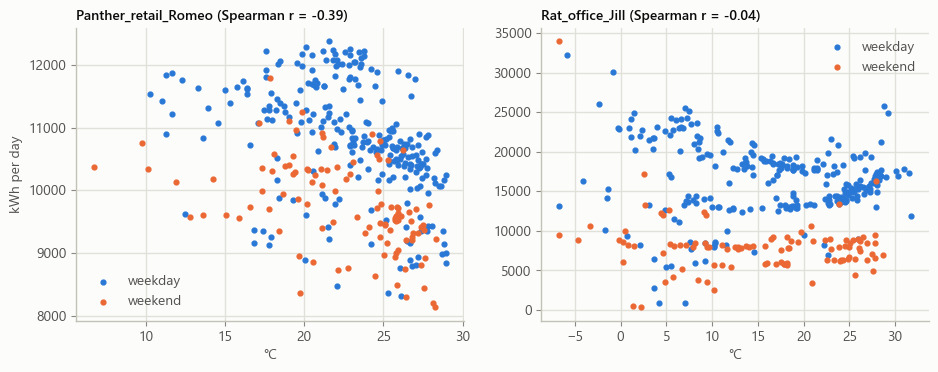

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, t in zip(axes, ['Retail', 'Office']):
    b = dim_b[dim_b['type'] == t].sort_values('floor_area_m2').iloc[-1]['building_id']
    d = daily[(daily['building_id'] == b) & daily['complete_day']]
    wk = d['date'].dt.dayofweek >= 5
    ax.scatter(d.loc[~wk, 'temp_mean_c'], d.loc[~wk, 'kwh'], s=12, color=ps.SERIES[0], label='weekday')
    ax.scatter(d.loc[wk, 'temp_mean_c'], d.loc[wk, 'kwh'], s=12, color=ps.SERIES[1], label='weekend')
    r = d['temp_mean_c'].corr(d['kwh'], method='spearman')
    ax.set_title(f'{b} (Spearman r = {r:.2f})', fontsize=10); ax.set_xlabel('°C'); ax.legend()
axes[0].set_ylabel('kWh per day')
plt.show()

## 5. How spread out is efficiency?

EUI (annual kWh per m²) within each type. Comparing a building only with its own type is the point of benchmarking.

In [6]:
annual.merge(dim_b[['building_id', 'type']], on='building_id').groupby('type')['eui_kwh_m2'].describe().round(1)

,count,mean,std,min,25%,50%,75%,max
type,,,,,,,,
Office,16.0,145.7,62.9,44.9,103.0,142.6,183.6,239.9
Retail,9.0,185.5,125.4,51.4,94.5,147.0,255.1,417.9


## 6. Where do the anomaly detectors fire?

Events per building and method. Remember: no ground truth, so this shows where to look, not which detector is right.

In [7]:
pivot = anom.pivot_table(index='building_id', columns='method', values='anomaly_id', aggfunc='count', fill_value=0)
pivot.sort_values('mad_baseline', ascending=False).head(10)

method,isolation_forest,mad_baseline,weather_regression
building_id,,,
Fox_retail_Manie,27,95,8
Wolf_office_Rochelle,26,71,0
Wolf_office_Cary,26,69,9
Wolf_office_Nadia,29,69,1
Wolf_office_Darleen,19,68,36
Wolf_retail_Toshia,48,66,0
Rat_office_Jill,19,60,5
Panther_retail_Kristina,42,59,0
Wolf_retail_Marcella,39,49,0


## Takeaways

* The data is real and mostly clean after validation; gaps and fills are flagged, never hidden.
* Weekday/weekend profiles show the opening-hours assumption is only roughly right, and differs by building.
* Temperature explains part of daily use for some buildings and very little for others, which is why the weather-normalised view is a separate check, not the main detector.
* Full numbers are in `RESULTS.md`, generated from the same run.